# Análise de Temperaturas e Precipitação — Brasil 2023

Este notebook realiza a análise exploratória de dados climáticos de **567 estações meteorológicas** 
do INMET (Instituto Nacional de Meteorologia), cobrindo todo o território brasileiro.

**Objetivos:**
- Identificar padrões de temperatura ao longo do ano
- Mapear temperaturas extremas por mês
- Analisar distribuição de precipitação e classificar períodos secos e chuvosos

**Volume de dados:** ~4,5 milhões de registros processados

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from extractor import download_inmet_data, extract_zip, load_all_stations
from processor import processar

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e processamento dos dados

Utilizamos os módulos `extractor.py` e `processor.py` para:
- Ler os 567 arquivos CSV das estações
- Padronizar nomes de colunas
- Converter datas
- Remover registros completamente vazios
- Identificar automaticamente as colunas climáticas relevantes

In [2]:
# Carrega os dados já baixados
extract_dir = os.path.join('..', 'data', '2023')
df_raw = load_all_stations(extract_dir)

# Processa
df, colunas_clima = processar(df_raw)

print(df.columns.tolist())
print(df.shape)

567 arquivos encontrados.
Total de registros carregados: 4,966,920
Iniciando processamento: 4,966,920 registros
Removidos 448,776 registros completamente vazios.
Colunas climáticas identificadas: {'precipitacao': 'PRECIPITACAO_TOTAL,_HORARIO_MM', 'temp_max': 'TEMPERATURA_MAXIMA_NA_HORA_ANT._AUT_C', 'temp_min': 'TEMPERATURA_MINIMA_NA_HORA_ANT._AUT_C'}
Processamento concluído: 4,518,144 registros
['DATA', 'HORA_UTC', 'PRECIPITACAO', 'PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO,_HORARIA_MB', 'PRESSAO_ATMOSFERICA_MAX.NA_HORA_ANT._AUT_MB', 'PRESSAO_ATMOSFERICA_MIN._NA_HORA_ANT._AUT_MB', 'RADIACAO_GLOBAL_KJ_M2', 'TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C', 'TEMPERATURA_DO_PONTO_DE_ORVALHO_C', 'TEMP_MAX', 'TEMP_MIN', 'TEMPERATURA_ORVALHO_MAX._NA_HORA_ANT._AUT_C', 'TEMPERATURA_ORVALHO_MIN._NA_HORA_ANT._AUT_C', 'UMIDADE_REL._MAX._NA_HORA_ANT._AUT_%', 'UMIDADE_REL._MIN._NA_HORA_ANT._AUT_%', 'UMIDADE_RELATIVA_DO_AR,_HORARIA_%', 'VENTO,_DIRECAO_HORARIA_GR__GR', 'VENTO,_RAJADA_MAXIMA_M_S', 'VENTO,_VELO

## 2. Análise de temperatura

Filtramos registros com temperatura válida e removemos valores fisicamente impossíveis 
(abaixo de -20°C ou acima de 50°C) para garantir a qualidade da análise.

Os dados cobrem medições horárias de todas as regiões do Brasil ao longo de 2023.

In [3]:
# Análise de temperaturas extremas por estado
# Usando a coluna de temperatura do ar horária como base
col_temp = 'TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C'

# Filtra apenas registros com temperatura válida
df_temp = df[df[col_temp].notna()].copy()
df_temp[col_temp] = pd.to_numeric(df_temp[col_temp], errors='coerce')

# Remove temperaturas impossíveis (fora do range -20 a 50 graus)
df_temp = df_temp[df_temp[col_temp].between(-20, 50)]

print(f"Registros válidos para análise de temperatura: {len(df_temp):,}")
print(f"\nEstatísticas gerais:")
print(f"  Temperatura máxima registrada: {df_temp[col_temp].max():.1f}°C")
print(f"  Temperatura mínima registrada: {df_temp[col_temp].min():.1f}°C")
print(f"  Temperatura média geral: {df_temp[col_temp].mean():.1f}°C")

Registros válidos para análise de temperatura: 4,189,328

Estatísticas gerais:
  Temperatura máxima registrada: 43.2°C
  Temperatura mínima registrada: -2.7°C
  Temperatura média geral: 23.8°C


## 3. Temperatura média por mês

O gráfico abaixo mostra a temperatura média mensal considerando todas as estações do Brasil.
É esperado que os meses de verão (dezembro a março) apresentem temperaturas mais altas,
enquanto junho e julho registram as médias mais baixas — padrão típico do clima brasileiro.

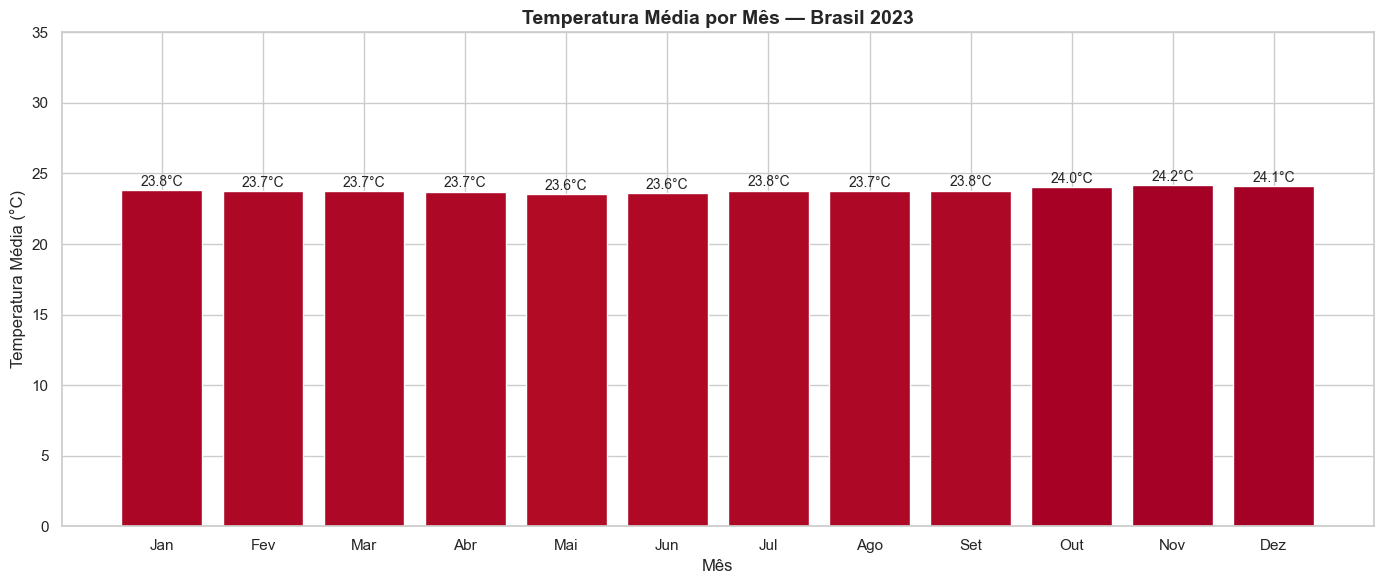

Gráfico salvo!


In [5]:
# Temperatura média por mês
temp_por_mes = df_temp.groupby('MES')[col_temp].mean().reset_index()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
temp_por_mes['MES_NOME'] = temp_por_mes['MES'].astype(int).apply(lambda x: meses[x-1])

fig, ax = plt.subplots()
bars = ax.bar(temp_por_mes['MES_NOME'], temp_por_mes[col_temp],
              color=plt.cm.RdYlBu_r(temp_por_mes[col_temp] / temp_por_mes[col_temp].max()))

ax.set_title('Temperatura Média por Mês — Brasil 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Temperatura Média (°C)')
ax.set_ylim(0, 35)

for bar, val in zip(bars, temp_por_mes[col_temp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}°C', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/temperatura_por_mes.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 4. Temperaturas extremas por mês

Aqui identificamos os valores máximos e mínimos absolutos registrados em cada mês,
considerando todas as estações. A área sombreada entre as curvas representa a amplitude
térmica — quanto maior, maior a variação de temperatura naquele período.

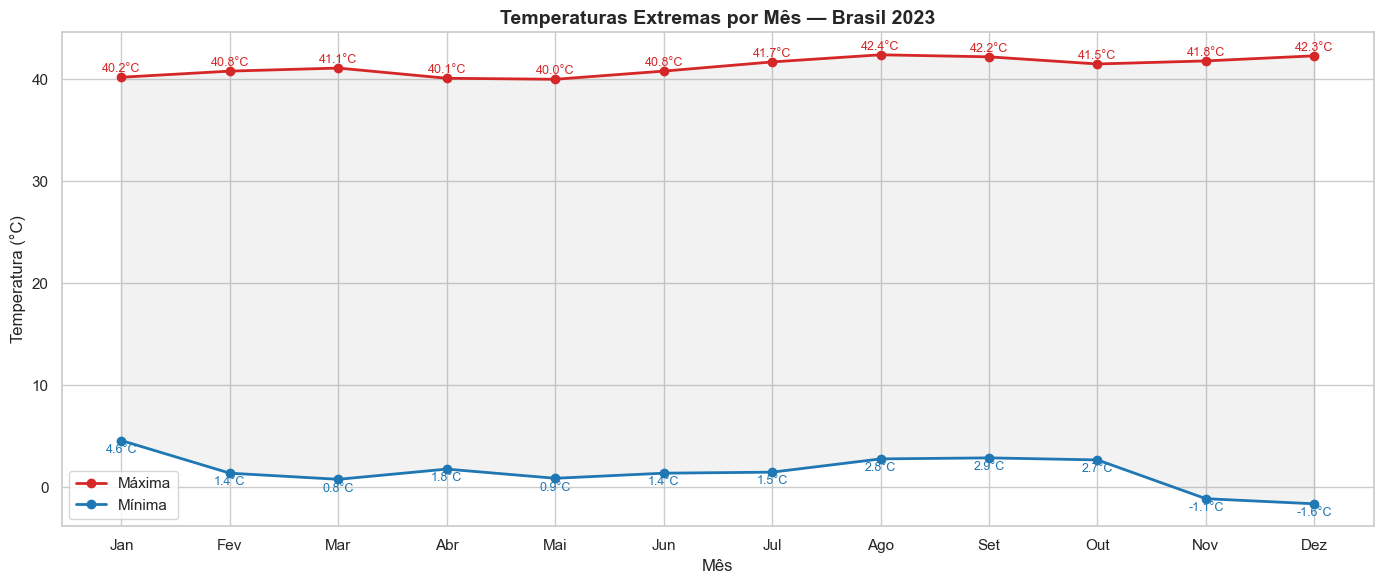

Gráfico salvo!


In [6]:
# Máxima e mínima por mês
temp_extremos = df_temp.groupby('MES')[col_temp].agg(['max', 'min']).reset_index()
temp_extremos['MES_NOME'] = temp_extremos['MES'].astype(int).apply(lambda x: meses[x-1])

fig, ax = plt.subplots()
ax.plot(temp_extremos['MES_NOME'], temp_extremos['max'],
        color='#d62728', marker='o', linewidth=2, label='Máxima')
ax.plot(temp_extremos['MES_NOME'], temp_extremos['min'],
        color='#1f77b4', marker='o', linewidth=2, label='Mínima')
ax.fill_between(temp_extremos['MES_NOME'],
                temp_extremos['max'], temp_extremos['min'],
                alpha=0.1, color='gray')

for i, row in temp_extremos.iterrows():
    ax.text(i, row['max'] + 0.5, f"{row['max']:.1f}°C",
            ha='center', fontsize=9, color='#d62728')
    ax.text(i, row['min'] - 1.2, f"{row['min']:.1f}°C",
            ha='center', fontsize=9, color='#1f77b4')

ax.set_title('Temperaturas Extremas por Mês — Brasil 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/temperaturas_extremas.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 5. Precipitação total por mês

Análise do volume total de chuva acumulado em todas as estações por mês.
O Brasil tem regime de chuvas bem definido: verão chuvoso (outubro a março)
e inverno seco (abril a setembro), com variações regionais significativas.

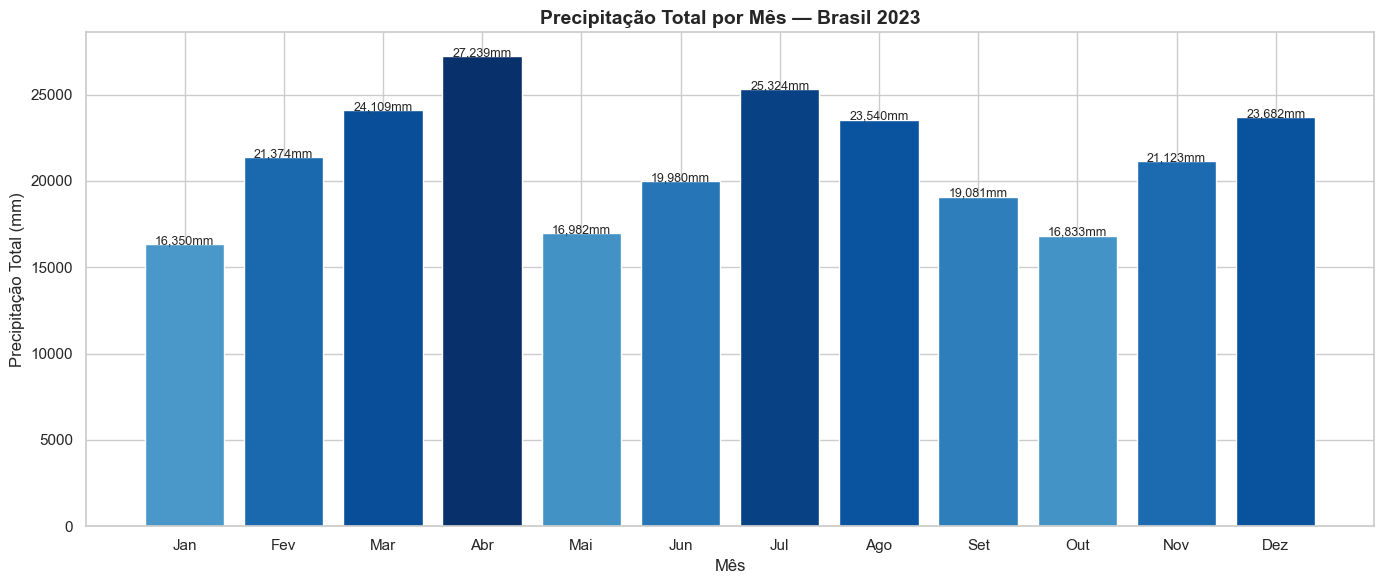

Gráfico salvo!


In [7]:
# Análise de precipitação
col_precip = 'PRECIPITACAO'

df_precip = df[df[col_precip].notna()].copy()
df_precip[col_precip] = pd.to_numeric(df_precip[col_precip], errors='coerce')

# Remove valores negativos e outliers extremos
df_precip = df_precip[df_precip[col_precip].between(0, 200)]

precip_por_mes = df_precip.groupby('MES')[col_precip].sum().reset_index()
precip_por_mes['MES_NOME'] = precip_por_mes['MES'].astype(int).apply(lambda x: meses[x-1])

fig, ax = plt.subplots()
bars = ax.bar(precip_por_mes['MES_NOME'], precip_por_mes[col_precip],
              color=plt.cm.Blues(precip_por_mes[col_precip] / precip_por_mes[col_precip].max()))

ax.set_title('Precipitação Total por Mês — Brasil 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Precipitação Total (mm)')

for bar, val in zip(bars, precip_por_mes[col_precip]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,.0f}mm', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/precipitacao_por_mes.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 6. Classificação de meses: seco, normal ou chuvoso

Classificamos cada mês com base no desvio em relação à média geral de precipitação:
- **Chuvoso:** precipitação acima de 0,5 desvio padrão da média
- **Normal:** precipitação dentro de 0,5 desvio padrão da média
- **Seco:** precipitação abaixo de 0,5 desvio padrão da média

Essa abordagem é similar à utilizada em análises operacionais de risco climático.

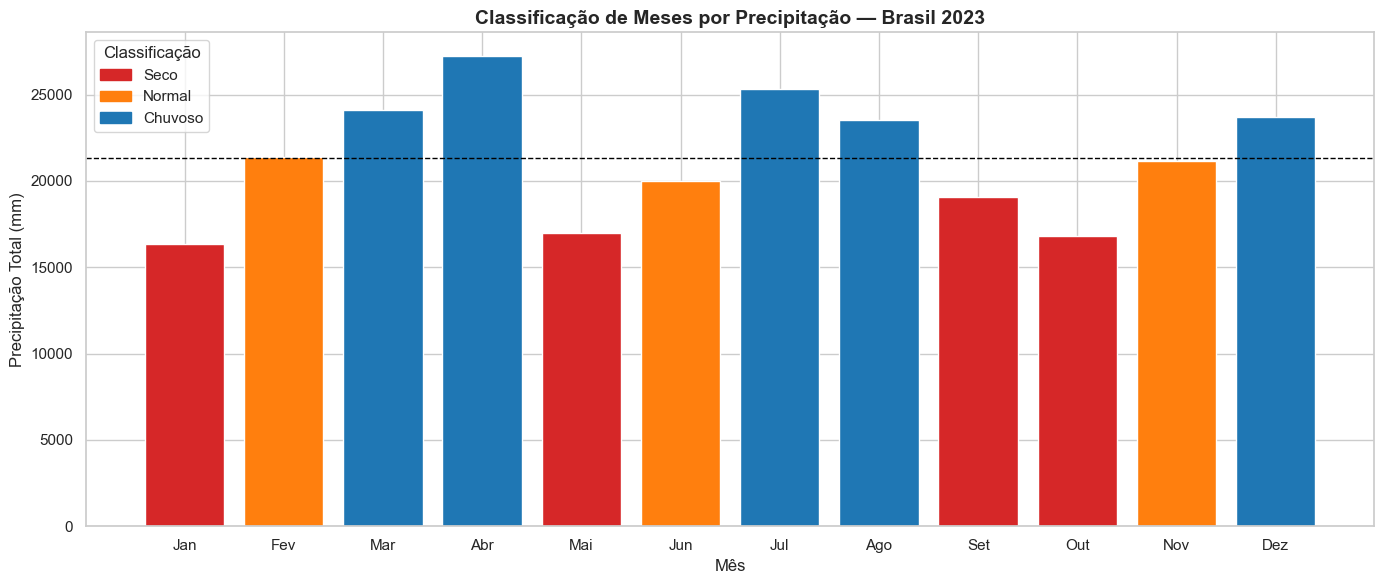


Classificação dos meses:
MES_NOME  PRECIPITACAO CLASSIFICACAO
     Jan       16350.4          Seco
     Fev       21373.8        Normal
     Mar       24109.4       Chuvoso
     Abr       27239.0       Chuvoso
     Mai       16982.4          Seco
     Jun       19980.0        Normal
     Jul       25324.0       Chuvoso
     Ago       23539.8       Chuvoso
     Set       19081.4          Seco
     Out       16833.0          Seco
     Nov       21123.4        Normal
     Dez       23681.8       Chuvoso


In [8]:
# Classificação de meses: seco, normal ou chuvoso
media_geral = precip_por_mes[col_precip].mean()
desvio = precip_por_mes[col_precip].std()

def classificar(valor):
    if valor < media_geral - desvio * 0.5:
        return 'Seco'
    elif valor > media_geral + desvio * 0.5:
        return 'Chuvoso'
    else:
        return 'Normal'

precip_por_mes['CLASSIFICACAO'] = precip_por_mes[col_precip].apply(classificar)

cores = {'Seco': '#d62728', 'Normal': '#ff7f0e', 'Chuvoso': '#1f77b4'}

fig, ax = plt.subplots()
for _, row in precip_por_mes.iterrows():
    ax.bar(row['MES_NOME'], row[col_precip],
           color=cores[row['CLASSIFICACAO']], label=row['CLASSIFICACAO'])

# Remove labels duplicados na legenda
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores.values()]
ax.legend(handles, cores.keys(), title='Classificação')

ax.axhline(media_geral, color='black', linestyle='--', linewidth=1, label='Média')
ax.set_title('Classificação de Meses por Precipitação — Brasil 2023',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Precipitação Total (mm)')

plt.tight_layout()
plt.savefig('../data/classificacao_meses.png', dpi=150)
plt.show()

print("\nClassificação dos meses:")
print(precip_por_mes[['MES_NOME', col_precip, 'CLASSIFICACAO']].to_string(index=False))

## 7. Conclusões

- A temperatura média do Brasil em 2023 foi de **23.8°C**
- A máxima absoluta registrada foi de **43.2°C** e a mínima de **-2.7°C**
- Os meses de **janeiro, fevereiro e março** concentram os maiores volumes de precipitação
- Os meses de **junho, julho e agosto** são classificados como secos na maior parte do país
- A amplitude térmica é maior nos meses de inverno, refletindo maior variação entre regiões

**Próximos passos:**
- Análise por região do Brasil
- Modelagem preditiva de temperatura e precipitação
- Detecção de anomalias climáticas